research code on image generation for product images

In [22]:
%load_ext autoreload
%autoreload 2

In [46]:
import json
from typing import Literal
import openai
import replicate
from pydantic import BaseModel
from dataclasses import dataclass
from typing import Any

oai = openai.Client()
rep = replicate.Client()


@dataclass
class ImageGen:
    url: str
    img_bytes: bytes
    prompt: str
    raw_output: Any
    raw_input: Any

    def show(self):
        from IPython.display import Image, display

        display(Image(data=self.img_bytes))


def run_seedreamv4(prompt: str) -> ImageGen:
    input = {
        "size": "2K",
        "width": 2048,
        "height": 2048,
        "prompt": prompt,
        "max_images": 1,
        "image_input": [],
        "aspect_ratio": "1:1",
        "enhance_prompt": False,
        "sequential_image_generation": "disabled",
    }
    output = rep.run(
        "bytedance/seedream-4",
        input=input,
    )
    out = ImageGen(
        url=output[0].url,
        img_bytes=output[0].read(),
        prompt=prompt,
        raw_output=output,
        raw_input=input,
    )
    return out


# represents a single product that user's tryna sell
class ProductInput(BaseModel):
    product_imgs: list[str]
    no_bg_img: str
    description: str
    industry: str
    target_audience: str
    hashtags: list[str]
    keywords_for_pinterest: list[str]
    extra_info: str

    def image_url(self) -> str:
        return self.product_imgs[0]


def remove_background(img_url: str) -> str:
    # use nano banana to remove bg for clean product img
    output = rep.run(
        "google/nano-banana",
        input={
            "prompt": "a clean product image with white background, centered product, high quality, well lit, studio lighting",
            "image_input": [img_url],
            "aspect_ratio": "match_input_image",
            "output_format": "jpg",
        },
    )
    return output.url


def process_product_input(img_url: str) -> ProductInput:
    """
    Analyzes the product img input and breaks it down
    """
    no_bg_img_url = remove_background(img_url)
    sys_rompt = """
    You are expert in ads creative and social media marketing. YOUR ONLY job is to analyze the product image details, analyze its target audience(demographics, interests, geogrpahics, etc). some hashtags about for the product.

    Topline goal is to provide as much detailed context for this product in terms of how to best market it on social media platforms. Ctx later will be used in downstream services like finding similar products, generating ad creatives, etc. It's extremely important to be precise, accurate, detailed.

    keywords_for_pinterest: used for finding similar products / context images on pinterest. these are the style reference / similar product imgs.

    extra_info: any other critical info

    ## BEGIN RULES
    closely follow the rules here.
    1. you can ignore product_imgs field, it's just for reference, ignore no_bg_img_url as well.

    ## END RULES
    """
    response = oai.responses.parse(
        model="gpt-4.1",
        input=[
            {"role": "system", "content": sys_rompt},
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_text",
                        "text": "here is my product",
                    },
                    {
                        "type": "input_image",
                        "image_url": no_bg_img_url,
                    },
                ],
            },
        ],
        text_format=ProductInput,
    )
    parsed = response.output_parsed
    parsed.product_imgs = [img_url]
    parsed.no_bg_img = no_bg_img_url
    return parsed


class ProductPrompt(BaseModel):
    state: Literal["rejected", "completed"]
    prompt: str
    rejection_reason: str | None = None


def gen_prompt_for_product(product_input: ProductInput) -> ProductPrompt:
    sys_promt = """
    You are expert in ads creative and social media marketing. YOUR ONLY job is to search, and generate prompt that I can use to create images for my products used in ads or social media campaigns.

    I will give you a brief of what product I'm selling, and you will search online for relevant images/ads to get some insights and find the closest one, and identify its composition, elements, details, layout, everything, and make some changes to the specifics, and eventually give me an image PROMPT that can be used to generate img.

    Then I will upload my product image and your prompt to get the final img.


    ## BEGIN RULES
    closely follow, order/sequence does not matter.
    1. output a 1-2 paragraph, plain text prompt, closely follow the image prompt guide for best practices.
    2. Optimize for social visuals and quality
    3. use the tools to read the appendix required docs, resources, etc
    4. include details like camera lens, lighting condition, overall color toning, layout of the scene(objects, and their positioning, and the background), depth of field. BE specific, effective.
    5. DONT mention aspect ratio, we will configure it as params.
    6. at the end of prompt, add negative_prompt to indicate elements/behaviors that you dont want, e.g. malformed arms, multiple hands/fingers, blurry, distortions, etc.

    Negative prompts
    The previous examples focus on writing prompts for what you want Imagen to create, but you can also provide a negative prompt along with the original prompt to help the product generate or edit images. These negative prompts can be a powerful tool that helps specify what elements to omit from the image. Simply describe what you don't want.

    Recommended — Plainly describe what you don't want to see. For example "wall, frame".

    Not recommended — Avoid instructive language or words like "no" or "don't". For example, avoid phrases like "no walls" or "don't show walls".
    7. to show precise texsts, put them within double quotes.

    ## END RULES



    ## BEGIN KNOWLEDGE
    1. we identify the following categories for different kinds of images, NOTE that the list is not exclusive, but just for your reference and guidance. Use your best judgement call on what are the target audience group, the product itself, and the destination where the content be, to decide what kind of product images 

    A. product shot show case, this is for just a product in the img with background/scene.
    B. usage effect showcase. e.g. skincare / beauty producst will have model and a half-body portrait with studio light, glowy skin, close-up shots, to show case what it looks like whne using it. more examples are. pandora bracelets, half-face korean close-up shots for lipsticks
    C. instagram, lifestyle, luxury lifestyle, cozy --> this is particularly good for showcasing lifestyle / products and its having great traction on IG due toe it's UGC, realism, and creator-based traction.
    D. more to come. 
    ## END KNOWLEDGE


    ## Appendix
    1. Image model Prompt Guide: https://bytedance.larkoffice.com/docx/PBvldM6Xlo5OHKxsRNVcyAq4nFe
    2. Advanced prompt writing techniques: https://cloud.google.com/vertex-ai/generative-ai/docs/image/img-gen-prompt-guide
    """

    res = oai.responses.parse(
        model="gpt-4.1",
        input=[
            {"role": "system", "content": sys_promt},
            {
                "role": "user",
                "content": json.dumps(product_input.model_dump_json()),
            },
        ],
        text_format=ProductPrompt,
    )
    return res.output_parsed

In [ ]:
product_input = process_product_input(
    "https://i.pinimg.com/1200x/7e/a4/fb/7ea4fb636fc6dfc311dc56ae8bdef3b4.jpg"
)
print(product_input)

In [48]:
prompt = gen_prompt_for_product(product_input)

In [49]:
output = run_seedreamv4(prompt.prompt)

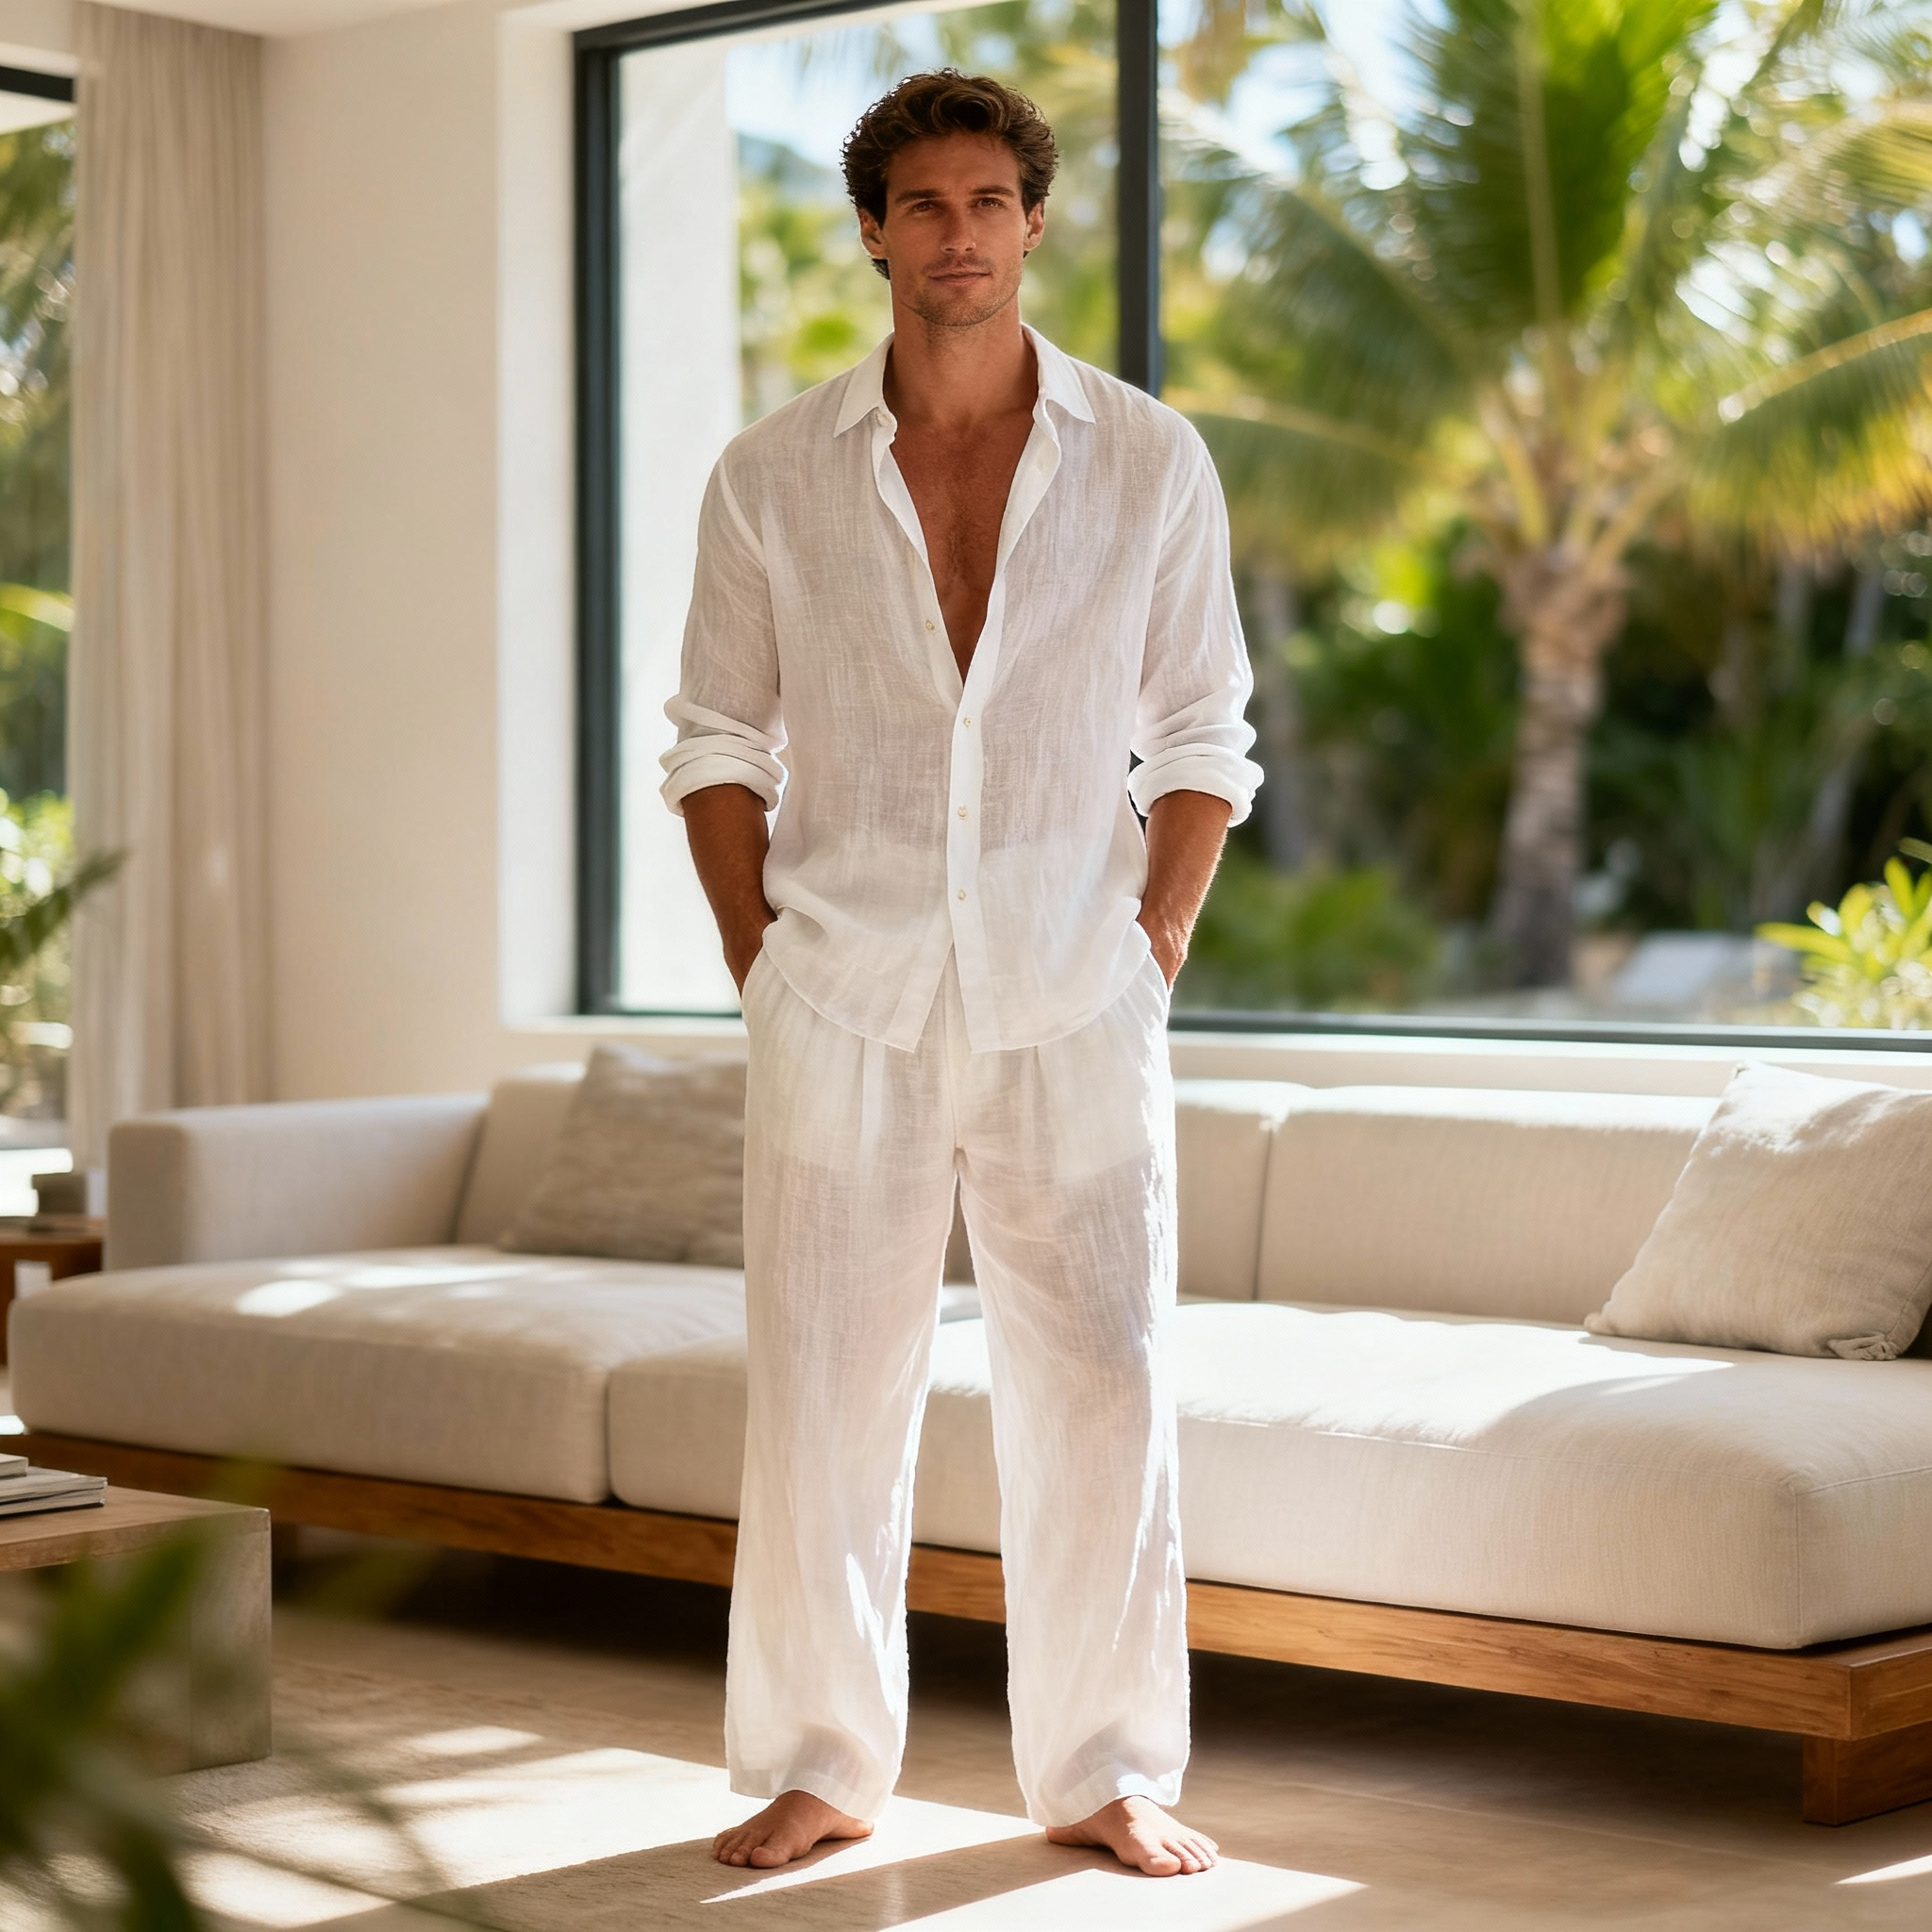

In [50]:
output.show()

In [54]:
product_input.no_bg_img

'https://replicate.delivery/xezq/63LOHeJSdvw3A67w4CAUBBpR8B9kcnWfeqUgnFVbkngEa4ErA/tmps9kvrajw.jpeg'

In [ ]:
sys_prompt_for_image_to_prompt = """
Your job is to given any image, output a 1-2 paragraph detailed image prompt for that. It will be very accurate, descriptive, concise, effective, for reproducing the img.

The prompt should be cover all the details including subjects, lighting, texture, coloring, layout, styles, everything for maximizing the accuracy of prompt. Also include negative prompts when needed.


// PROMPT GUIDE for images //

Image text: A sketch (style) of a modern apartment building (subject) surrounded by skyscrapers (context and background).
Subject: The first thing to think about with any prompt is the subject: the object, person, animal, or scenery you want an image of.

Context and background: Just as important is the background or context in which the subject will be placed. Try placing your subject in a variety of backgrounds. For example, a studio with a white background, outdoors, or indoor environments.

Style: Finally, add the style of image you want. Styles can be general (painting, photograph, sketches) or very specific (pastel painting, charcoal drawing, isometric 3D).

Additional advice for Imagen 3 prompt writing:

Use descriptive language: Employ detailed adjectives and adverbs to paint a clear picture for Imagen 3.
Provide context: If necessary, include background information to aid the AI's understanding.
Reference specific artists or styles: If you have a particular aesthetic in mind, referencing specific artists or art movements can be helpful.
Use prompt engineering tools: Consider exploring prompt engineering tools or resources to help you refine your prompts and achieve optimal results.
Enhancing the facial details in your personal and group images:
Specify facial details as a focus of the photo (for example, use the word "portrait" in the prompt).
Consider using a larger model like Imagen 3 instead of Imagen 3 Fast to improve detail.


Photography modifiers
In the following examples, you can see several photography-specific modifiers and parameters.

Camera Proximity - Close up, taken from far away


close up camera sample image
Prompt: A close-up photo of coffee beans
zoomed out camera sample image
Prompt: A zoomed out photo of a small bag of
coffee beans in a messy kitchen
Camera Position - aerial, from below

aerial photo sample image
Prompt: aerial photo of urban city with skyscrapers
a view from underneath sample image
Prompt: A photo of a forest canopy with blue skies from below
Lighting - natural, dramatic, warm, cold

natural lighting sample image
Prompt: studio photo of a modern arm chair, natural lighting
dramatic lighting sample image
Prompt: studio photo of a modern arm chair, dramatic lighting
Camera Settings - motion blur, soft focus, bokeh, portrait

motion blur sample image
Prompt: photo of a city with skyscrapers from the inside of a car with motion blur
soft focus sample image
Prompt: soft focus photograph of a bridge in an urban city at night
Lens types - 35mm, 50mm, fisheye, wide angle, macro

macro lens sample image
Prompt: photo of a leaf, macro lens
fisheye lens sample image
Prompt: street photography, new york city, fisheye lens
Film types - black and white, polaroid

polaroid photo sample image
Prompt: a polaroid portrait of a dog wearing sunglasses
black and white photo sample image
Prompt: black and white photo of a dog wearing sunglasses
Image source: Each image was generated using its corresponding text prompt with the Imagen 3 model.

Shapes and materials
Prompt includes: "...made of...", "...in the shape of..."

Negative prompts
The previous examples focus on writing prompts for what you want Imagen to create, but you can also provide a negative prompt along with the original prompt to help the product generate or edit images. These negative prompts can be a powerful tool that helps specify what elements to omit from the image. Simply describe what you don't want.

Recommended — Plainly describe what you don't want to see. For example "wall, frame".

Not recommended — Avoid instructive language or words like "no" or "don't". For example, avoid phrases like "no walls" or "don't show walls".

Photorealistic images:

Use case	Lens type	Focal lengths	Additional details
People (portraits)	Prime, zoom	24-35mm	black and white film, Film noir, Depth of field, duotone (mention two colors)
Food, insects, plants (objects, still life)	Macro	60-105mm	High detail, precise focusing, controlled lighting
Sports, wildlife (motion)	Telephoto zoom	100-400mm	Fast shutter speed, Action or movement tracking
Astronomical, landscape (wide-angle)	Wide-angle	10-24mm	Long exposure times, sharp focus, long exposure, smooth water or clouds

Use case	Lens type	Focal lengths	Additional details
People (portraits)	Prime, zoom	24-35mm	black and white film, Film noir, Depth of field, duotone (mention two color

Objects
Use case	Lens type	Focal lengths	Additional details
Food, insects, plants (objects, still life)	Macro	60-105mm	High detail, precise focusing, controlled lighting


Motion
Use case	Lens type	Focal lengths	Additional details
Sports, wildlife (motion)	Telephoto zoom	100-400mm	Fast shutter speed, Action or movement tracking

Wide-angle
Use case	Lens type	Focal lengths	Additional details
Astronomical, landscape (wide-angle)	Wide-angle	10-24mm	Long exposure times, sharp focus, long exposure, smooth water or clouds


"""